# Lucrare de laborator nr. 2 — Autoencoder clasic și Variational Autoencoder pe MNIST

**Scop:** implementarea, antrenarea și compararea a două arhitecturi encoder–decoder, un autoencoder clasic (AE) și un Variational Autoencoder (VAE), pentru comprimarea, reconstruirea și generarea imaginilor MNIST.

**Structura raportului**

1. Date
2. Arhitecturi
3. Antrenare (AE și VAE)
4. Evoluția în timpul antrenării
5. Comparație: reconstrucție
6. Comparație: generare
7. Spațiul latent
8. Concluzii

Codul modelelor se află în `src/` (`data.py`, `autoencoder.py`, `vae.py`). Raportul le importă, ca aceleași funcții să fie folosite și la antrenare, și în aplicația interactivă `app_desen.py`.

In [1]:
import os, sys, json
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "3")
sys.path.insert(0, os.getcwd())
import logging, warnings
logging.getLogger("tensorflow").setLevel(logging.ERROR)
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import tensorflow as tf
from tensorflow import keras
tf.get_logger().setLevel("ERROR")   # dupa import: TF isi reseteaza logger-ul la import

from src.data import incarca_mnist
from src.autoencoder import construieste_autoencoder
from src.vae import construieste_vae
from src.checkpointuri import SalveazaLaEpoci

# Culori: AE = albastru, VAE = portocaliu (paleta validata si pentru daltonism).
C_AE, C_VAE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "text.color": "#0b0b0b",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "lines.linewidth": 2, "font.size": 10, "axes.axisbelow": True,
})

DIR = Path(".")

## 1. Date

MNIST: 60 000 de imagini de antrenare și 10 000 de test, 28×28 pixeli, tonuri de gri. Setul vine ca `uint8` (0–255) și îl normalizăm în `[0, 1]`: ultimul strat al decoderului e `sigmoid`, iar loss-ul, binary crossentropy, tratează fiecare pixel ca probabilitatea de a fi aprins.

Etichetele (cifra reală) **nu se folosesc la antrenare**. Ambele modele sunt nesupervizate: ținta este chiar imaginea de intrare. Etichetele servesc doar la analiză.

In [2]:
x_train, x_test, y_train, y_test = incarca_mnist()
print(f"antrenare: {x_train.shape}, test: {x_test.shape}, interval [{x_train.min():.0f}, {x_train.max():.0f}]")
print(f"pixeli de fundal (<0.1): {(x_train < 0.1).mean()*100:.1f}%   "
      f"intermediari (0.1-0.9): {((x_train >= 0.1) & (x_train <= 0.9)).mean()*100:.1f}%")

# Podeaua BCE: chiar si o copie perfecta are cost nenul din cauza pixelilor
# intermediari. Progresul real se masoara fata de aceasta valoare, nu fata de 0.
p = np.clip(x_test, 1e-7, 1 - 1e-7)
PODEA_BCE = float(np.mean(-(x_test*np.log(p) + (1-x_test)*np.log(1-p))))
print(f"podea BCE (copie perfecta): {PODEA_BCE:.4f}")

antrenare: (60000, 784), test: (10000, 784), interval [0, 1]
pixeli de fundal (<0.1): 82.6%   intermediari (0.1-0.9): 8.7%


podea BCE (copie perfecta): 0.0581


## 2. Arhitecturi

Ambele modele au aceleași straturi, ca diferențele măsurate să vină doar din ce e diferit conceptual.

| | AE clasic | VAE |
|---|---|---|
| Encoder | 784 → 128 → 64 → **z (32)** | 784 → 128 → 64 → **μ (32), log σ² (32)** |
| Cod latent | un punct, determinist | eșantionat: z = μ + σ · ε, ε ~ N(0,1) |
| Decoder | 32 → 64 → 128 → 784 (sigmoid) | identic |
| Loss | BCE(x, x̂) | BCE sumată pe pixeli + KL(N(μ, σ²) ‖ N(0,1)), β = 1 |

- **Activări:** ReLU pe straturile ascunse. Fără ele, straturile se colapsează algebric într-o singură transformare liniară (măsurat: 3 straturi fără ReLU dau același rezultat ca unul singur).
- **Stratul latent e liniar** la ambele modele. ReLU acolo ar tăia valorile negative (măsurat: 4 din 32 de dimensiuni moarte).
- **VAE:** encoderul descrie pentru fiecare imagine un *nor* (centru μ, lățime σ), nu un punct. Termenul KL trage toți norii spre N(0,1), astfel încât spațiul latent să nu aibă goluri.
- **Reconstrucția VAE e sumată pe cei 784 de pixeli**, nu mediată. Doar așa β = 1 corespunde formulării originale. Cu medie (implicitul din Keras), modelul a colapsat complet: KL = 0 și 0 din 32 de dimensiuni folosite.

In [3]:
ae, ae_enc, ae_dec = construieste_autoencoder()
vae, vae_enc, vae_dec = construieste_vae(beta=1.0, reducere="suma")
print(f"AE : {ae.count_params():,} parametri")
print(f"VAE: {vae.count_params():,} parametri  (+2 080 pentru capul log_var)")

AE : 222,384 parametri
VAE: 224,464 parametri  (+2 080 pentru capul log_var)


## 3. Antrenare

**Criteriul de oprire:** antrenăm până când îmbunătățirea devine neglijabilă, nu un număr fix de epoci. `EarlyStopping` pe `val_loss` cu `min_delta` = 0.0001 per pixel (≈ 1/300 din eroarea rămasă după 30 de epoci), `patience` = 10, plafon 300 de epoci, iar la final se restaurează greutățile celei mai bune epoci.

Loss-ul VAE e o sumă pe 784 de pixeli, deci pragul echivalent e 0.0001 × 784. Fără această scalare, VAE ar fi judecat mult mai strict decât AE și comparația n-ar fi corectă.

Se salvează greutăți intermediare la epocile 1, 5, 20, 50 și la final, pentru secțiunea 4. Antrenarea durează ~4 minute per model pe CPU. Cu `ANTRENEAZA = False` se încarcă greutățile deja salvate.

In [4]:
ANTRENEAZA = False
EPOCI_CKPT = [1, 5, 20, 50, 130]

def antreneaza(model, prefix, min_delta, fisier_istoric):
    keras.utils.set_random_seed(42)
    oprire = keras.callbacks.EarlyStopping(monitor="val_loss", min_delta=min_delta,
                                           patience=10, restore_best_weights=True)
    ckpt = SalveazaLaEpoci(EPOCI_CKPT, prefix=prefix)
    h = model.fit(x_train, x_train,          # tinta = intrarea: fara etichete
                  epochs=300, batch_size=256, shuffle=True, validation_split=0.1,
                  callbacks=[oprire, ckpt], verbose=0)
    model.save_weights(DIR / "checkpoints" / f"{prefix}_final.weights.h5")
    ist = {k: [float(v) for v in vals] for k, vals in h.history.items()}
    with open(DIR / "istoric" / fisier_istoric, "w", encoding="utf-8") as f:
        json.dump({"istoric": ist, "epoca_best": int(np.argmin(ist["val_loss"])) + 1,
                   "epoci_rulate": len(ist["loss"]), "epoci_ckpt": ckpt.salvate}, f, indent=2)

if ANTRENEAZA or not (DIR / "modele" / "vae.weights.h5").exists():
    ae.compile(optimizer="adam", loss="binary_crossentropy")
    antreneaza(ae, "ae", 0.0001, "ae_clasic.json")
    ae.save_weights(DIR / "modele" / "ae_clasic.weights.h5")

    vae.compile(optimizer="adam")
    antreneaza(vae, "vae", 0.0001 * 784, "vae.json")
    vae.save_weights(DIR / "modele" / "vae.weights.h5")

ae.load_weights(DIR / "modele" / "ae_clasic.weights.h5")
vae.load_weights(DIR / "modele" / "vae.weights.h5")
ist_ae = json.load(open(DIR / "istoric" / "ae_clasic.json", encoding="utf-8"))
ist_vae = json.load(open(DIR / "istoric" / "vae.json", encoding="utf-8"))
for nume, d in [("AE", ist_ae), ("VAE", ist_vae)]:
    print(f"{nume}: {d['epoci_rulate']} epoci rulate, cea mai buna epoca {d['epoca_best']}")

AE: 134 epoci rulate, cea mai buna epoca 130
VAE: 126 epoci rulate, cea mai buna epoca 124


### Curbele de antrenare

Ambele curbe sunt BCE medie per pixel pe setul de validare, deci au aceeași unitate și se pot compara pe aceeași axă. La VAE, BCE e măsurată cu z eșantionat, adică include zgomotul norului. KL apare separat, pe propriul grafic, pentru că are altă unitate.

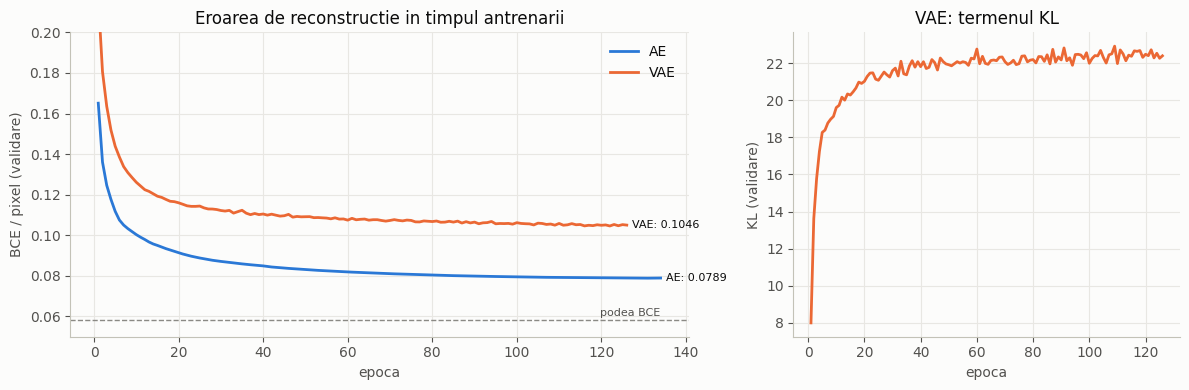

In [5]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.6, 1]})
va_ae = ist_ae["istoric"]["val_loss"]
va_vae = ist_vae["istoric"]["val_bce_pixel"]
a1.plot(range(1, len(va_ae) + 1), va_ae, color=C_AE, label="AE")
a1.plot(range(1, len(va_vae) + 1), va_vae, color=C_VAE, label="VAE")
a1.axhline(PODEA_BCE, color="#8a8984", ls="--", lw=1)
a1.text(len(va_ae), PODEA_BCE + 0.002, "podea BCE", color="#52514e", ha="right", fontsize=8)
for va, c, n in [(va_ae, C_AE, "AE"), (va_vae, C_VAE, "VAE")]:
    a1.annotate(f"{n}: {min(va):.4f}", (len(va), va[-1]), xytext=(4, 0),
                textcoords="offset points", color="#0b0b0b", fontsize=8, va="center")
a1.set(xlabel="epoca", ylabel="BCE / pixel (validare)", ylim=(0.05, 0.2),
       title="Eroarea de reconstructie in timpul antrenarii")
a1.legend(frameon=False)

kl = ist_vae["istoric"]["val_kl"]
a2.plot(range(1, len(kl) + 1), kl, color=C_VAE)
a2.set(xlabel="epoca", ylabel="KL (validare)", title="VAE: termenul KL")
plt.tight_layout(); plt.show()

## 4. Evoluția în timpul antrenării

Aceleași 5 imagini de test, trecute prin model la epocile 1, 5, 20, 50 și final. Primul rând e originalul.

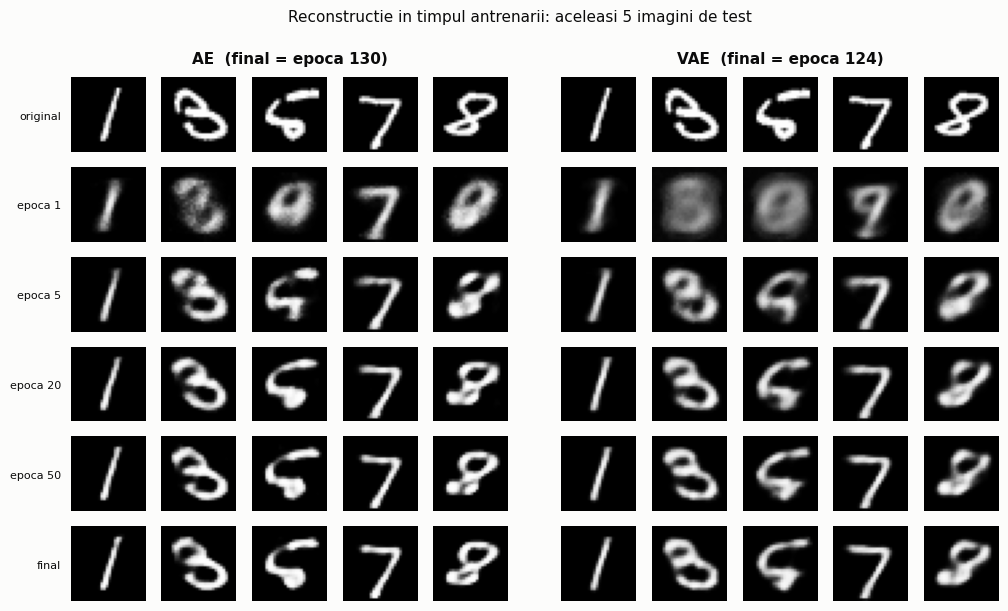

In [6]:
IDX = [int(np.where(y_test == c)[0][0]) for c in (1, 3, 5, 7, 8)]   # de la usor la greu
imagini = x_test[IDX]

def etape(prefix, ist):
    return [(f"epoca {e}", DIR / "checkpoints" / f"{prefix}_ep{e:03d}.weights.h5") for e in (1, 5, 20, 50)] + \
           [("final", DIR / "modele" / ("ae_clasic.weights.h5" if prefix == "ae" else "vae.weights.h5"))]

def cod_ae(x):  return ae_enc.predict(x, verbose=0)
def cod_vae(x): return vae_enc.predict(x, verbose=0)[0]     # mu: centrul norului

def bce(x, p):
    p = np.clip(p, 1e-7, 1 - 1e-7)
    return float(np.mean(-(x*np.log(p) + (1-x)*np.log(1-p))))

evolutie = {}
fig, axe = plt.subplots(6, 11, figsize=(12, 6.8), gridspec_kw={"width_ratios": [1]*5 + [0.3] + [1]*5})
for bloc, (nume, model, enc_f, dec, prefix, ist) in enumerate([
        ("AE", ae, cod_ae, ae_dec, "ae", ist_ae), ("VAE", vae, cod_vae, vae_dec, "vae", ist_vae)]):
    col0 = 0 if bloc == 0 else 6
    axe[0, col0 + 2].set_title(f"{nume}  (final = epoca {ist['epoca_best']})", fontsize=11, fontweight="bold", pad=10)
    for c in range(5):
        axe[0, col0 + c].imshow(imagini[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
    evolutie[nume] = []
    for r, (et, cale) in enumerate(etape(prefix, ist), start=1):
        model.load_weights(cale)
        rec = dec.predict(enc_f(imagini), verbose=0)
        evolutie[nume].append((et, bce(x_test, dec.predict(enc_f(x_test), verbose=0))))
        for c in range(5):
            axe[r, col0 + c].imshow(rec[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axe[r, col0].text(-4, 14, et if bloc == 0 else "", ha="right", va="center", fontsize=8)
for a in axe.ravel():
    a.axis("off")
axe[0, 0].text(-4, 14, "original", ha="right", va="center", fontsize=8)
fig.suptitle("Reconstructie in timpul antrenarii: aceleasi 5 imagini de test", fontsize=11)
plt.show()

ae.load_weights(DIR / "modele" / "ae_clasic.weights.h5")
vae.load_weights(DIR / "modele" / "vae.weights.h5")

Aceeași evoluție, măsurată pe toate cele 10 000 de imagini de test:

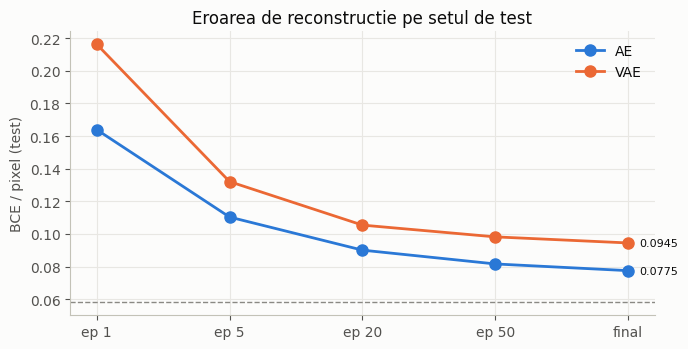

etapa                 AE       VAE
epoca 1           0.1639    0.2163
epoca 5           0.1104    0.1321
epoca 20          0.0901    0.1054
epoca 50          0.0816    0.0982
final             0.0775    0.0945


In [7]:
fig, ax = plt.subplots(figsize=(7, 3.6))
et_ae = [e for e, _ in evolutie["AE"]]
for nume, c in [("AE", C_AE), ("VAE", C_VAE)]:
    v = [b for _, b in evolutie[nume]]
    ax.plot(range(5), v, color=c, marker="o", markersize=8, label=nume)
    ax.annotate(f"{v[-1]:.4f}", (4, v[-1]), xytext=(8, 0), textcoords="offset points",
                va="center", fontsize=8)
ax.axhline(PODEA_BCE, color="#8a8984", ls="--", lw=1)
ax.set_xticks(range(5), ["ep 1", "ep 5", "ep 20", "ep 50", "final"])
ax.set(ylabel="BCE / pixel (test)", title="Eroarea de reconstructie pe setul de test")
ax.legend(frameon=False); plt.tight_layout(); plt.show()

print(f"{'etapa':<14}{'AE':>10}{'VAE':>10}")
for (e, a), (_, v) in zip(evolutie["AE"], evolutie["VAE"]):
    print(f"{e.split(' (')[0]:<14}{a:>10.4f}{v:>10.4f}")

### Generarea în timpul antrenării

Decoderul primește aceiași 5 vectori z, trași o singură dată din N(0,1), fără nicio imagine reală în spate. Așa se generează o imagine nouă cu un model antrenat:

```python
z = np.random.normal(0, 1, (5, 32))   # 5 coduri inventate
imagini_noi = vae_dec.predict(z)      # decoderul le transforma in imagini
```

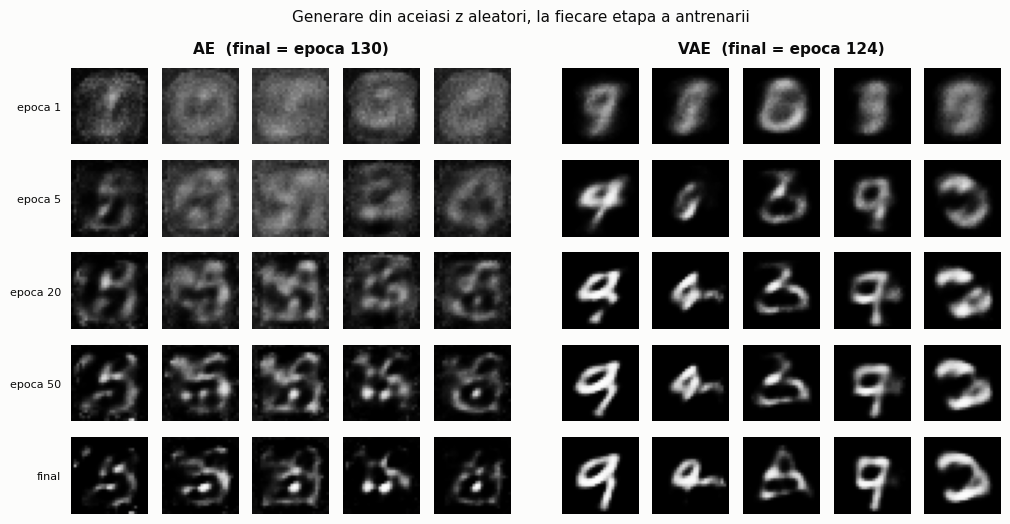

In [8]:
Z_FIX = np.random.default_rng(3).normal(0, 1, (5, 32)).astype("float32")
fig, axe = plt.subplots(5, 11, figsize=(12, 5.8), gridspec_kw={"width_ratios": [1]*5 + [0.3] + [1]*5})
for bloc, (nume, model, dec, prefix, ist) in enumerate([
        ("AE", ae, ae_dec, "ae", ist_ae), ("VAE", vae, vae_dec, "vae", ist_vae)]):
    col0 = 0 if bloc == 0 else 6
    for r, (et, cale) in enumerate(etape(prefix, ist)):
        model.load_weights(cale)
        gen = dec.predict(Z_FIX, verbose=0)
        for c in range(5):
            axe[r, col0 + c].imshow(gen[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        if bloc == 0:
            axe[r, 0].text(-4, 14, et, ha="right", va="center", fontsize=8)
    axe[0, col0 + 2].set_title(f"{nume}  (final = epoca {ist['epoca_best']})", fontsize=11, fontweight="bold", pad=10)
for a in axe.ravel():
    a.axis("off")
fig.suptitle("Generare din aceiasi z aleatori, la fiecare etapa a antrenarii", fontsize=11)
plt.show()
ae.load_weights(DIR / "modele" / "ae_clasic.weights.h5")
vae.load_weights(DIR / "modele" / "vae.weights.h5")

## 5. Comparație: reconstrucție (compresie)

Fiecare imagine de 784 de pixeli e comprimată în 32 de numere (24.5×) și reconstruită. La VAE se folosește μ, centrul norului, deci reconstrucția e deterministă, ca la AE.

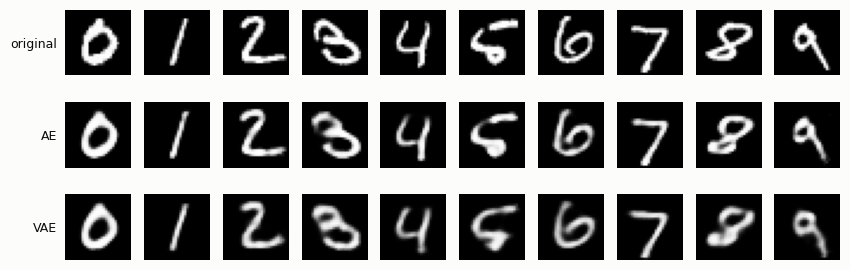

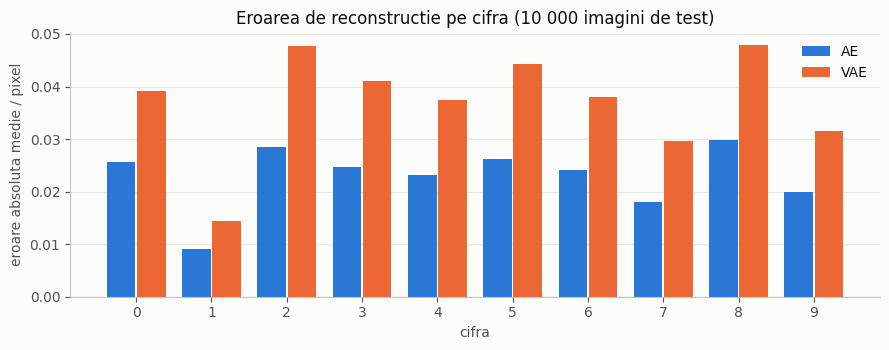

BCE / pixel pe test:  AE 0.0775   VAE 0.0945   (podea 0.0581)


In [9]:
idx10 = [int(np.where(y_test == c)[0][0]) for c in range(10)]
orig = x_test[idx10]
fig, axe = plt.subplots(3, 10, figsize=(10, 3.4))
for r, im in enumerate([orig, ae_dec.predict(cod_ae(orig), verbose=0),
                        vae_dec.predict(cod_vae(orig), verbose=0)]):
    for c in range(10):
        axe[r, c].imshow(im[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axe[r, c].axis("off")
for r, n in enumerate(["original", "AE", "VAE"]):
    axe[r, 0].text(-4, 14, n, ha="right", va="center", fontsize=9)
plt.show()

rec_ae = ae_dec.predict(cod_ae(x_test), verbose=0)
rec_vae = vae_dec.predict(cod_vae(x_test), verbose=0)
err_ae = [np.abs(x_test[y_test == c] - rec_ae[y_test == c]).mean() for c in range(10)]
err_vae = [np.abs(x_test[y_test == c] - rec_vae[y_test == c]).mean() for c in range(10)]

fig, ax = plt.subplots(figsize=(9, 3.6))
w = 0.38
ax.bar(np.arange(10) - w/2 - 0.01, err_ae, w, color=C_AE, label="AE")
ax.bar(np.arange(10) + w/2 + 0.01, err_vae, w, color=C_VAE, label="VAE")
ax.set_xticks(range(10)); ax.set(xlabel="cifra", ylabel="eroare absoluta medie / pixel",
                                 title="Eroarea de reconstructie pe cifra (10 000 imagini de test)")
ax.grid(axis="x", visible=False); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print(f"BCE / pixel pe test:  AE {bce(x_test, rec_ae):.4f}   VAE {bce(x_test, rec_vae):.4f}   (podea {PODEA_BCE:.4f})")

## 6. Comparație: generare

Testul central al laboratorului: z tras la întâmplare, fără nicio imagine de intrare. Pentru AE sunt două variante, ca eșecul să nu poată fi pus pe seama unei distribuții prost alese: N(0,1), și o normală cu media și deviația reale ale codurilor AE.

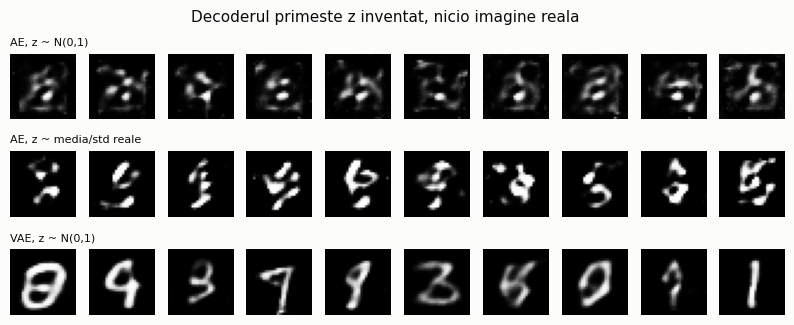

In [10]:
rng = np.random.default_rng(0)
Z_ae = cod_ae(x_test)
randuri = {
    "AE, z ~ N(0,1)": ae_dec.predict(rng.normal(0, 1, (10, 32)), verbose=0),
    "AE, z ~ media/std reale": ae_dec.predict(rng.normal(Z_ae.mean(0), Z_ae.std(0), (10, 32)), verbose=0),
    "VAE, z ~ N(0,1)": vae_dec.predict(rng.normal(0, 1, (10, 32)), verbose=0),
}
fig, axe = plt.subplots(3, 10, figsize=(10, 3.6))
for r, (n, im) in enumerate(randuri.items()):
    for c in range(10):
        axe[r, c].imshow(im[c].reshape(28, 28), cmap="gray", vmin=0, vmax=1)
        axe[r, c].axis("off")
    axe[r, 0].set_title(n, fontsize=8, loc="left", x=0)
fig.suptitle("Decoderul primeste z inventat, nicio imagine reala", fontsize=11)
plt.show()

## 7. Spațiul latent

De ce generează VAE și AE nu: un z tras la întâmplare trebuie să cadă aproape de coduri pe care decoderul le cunoaște. Măsurăm distanța de la un z aleator până la cel mai apropiat cod real, împărțită la distanța tipică dintre codurile reale vecine.

- **raport ≈ 1**: z aleator cade printre coduri reale (fără goluri)
- **raport ≫ 1**: z aleator cade în gol

La VAE măsurăm pe z eșantionat, adică pe norii întregi. Centrele μ singure sunt tot puncte izolate.

In [11]:
def raport_gol(Z, probe, r):
    real = Z[r.choice(len(Z), 300, replace=False)]
    d_real = [np.sort(np.linalg.norm(Z - p, axis=1))[1] for p in real]
    d_probe = [np.linalg.norm(Z - p, axis=1).min() for p in probe]
    return float(np.mean(d_probe) / np.mean(d_real))

r = np.random.default_rng(1)
mu, lv, Z_vae = vae_enc.predict(x_test, verbose=0)
kl_dim = (-0.5 * (1 + lv - mu**2 - np.exp(lv))).mean(0)
gol_ae = raport_gol(Z_ae, r.normal(Z_ae.mean(0), Z_ae.std(0), (300, 32)), r)
gol_vae = raport_gol(Z_vae, r.normal(0, 1, (300, 32)), r)
gol_ideal = raport_gol(r.normal(0, 1, (10000, 32)), r.normal(0, 1, (300, 32)), r)

print(f"{'':<30}{'AE':>10}{'VAE':>10}")
print("-" * 50)
print(f"{'raport gol (1 = fara gol)':<30}{gol_ae:>10.2f}{gol_vae:>10.2f}   (N(0,1) ideal: {gol_ideal:.2f})")
print(f"{'dimensiuni latente folosite':<30}{'32/32':>10}{f'{int((kl_dim > 0.01).sum())}/32':>10}")

                                      AE       VAE
--------------------------------------------------
raport gol (1 = fara gol)           1.95      1.05   (N(0,1) ideal: 0.99)
dimensiuni latente folosite        32/32     16/32


VAE nu folosește toate cele 32 de dimensiuni. KL penalizează fiecare dimensiune care se abate de la N(0,1), așa că modelul le păstrează doar pe cele utile reconstrucției, iar restul rămân zgomot pur, ignorat de decoder. Un VAE separat, antrenat cu z de 16 dimensiuni, a folosit 14 din 16, cu reconstrucție doar puțin mai slabă (BCE 0.0970 față de 0.0945) și o generare comparabilă.

### Harta spațiului latent

Unde cade fiecare imagine de test în spațiul latent, proiectat din 32 de dimensiuni în 2 cu PCA (cele două direcții cu cea mai mare variație). Proiecția e o umbră: puncte departe în 32D pot cădea aproape în 2D. Titlul fiecărui panou arată cât din variație păstrează proiecția.

- **Gri:** toate cele 10 000 de imagini de test. Cifra scrisă pe hartă marchează mijlocul zonei ei.
- **AE:** 25 de imagini alese la întâmplare, fiecare **un punct**.
- **VAE:** aceleași 25 de imagini, fiecare **un nor** (elipsa la 2σ), cu centrul μ.

Etichetele nu intră în model. Gruparea pe cifre apare singură, din compresie.

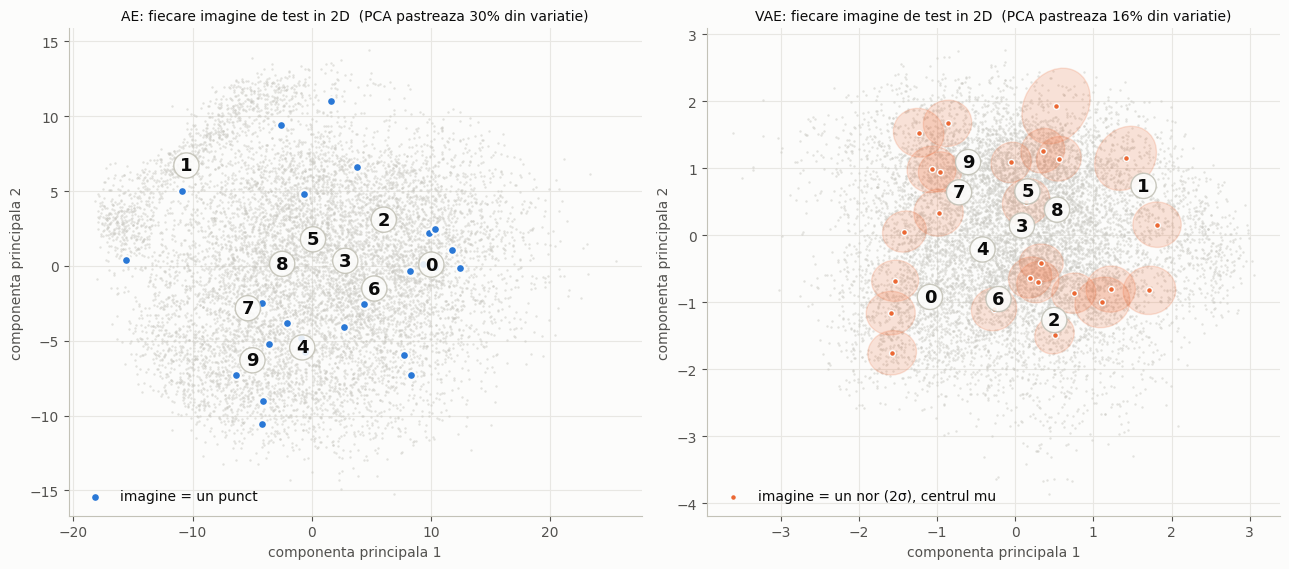

intinderea hartii: AE ~ [43.7 29.6], VAE ~ [6.7 6.6]  (axele difera: KL tine codurile VAE aproape de origine)


In [12]:
from matplotlib.patches import Ellipse
from src.latent import ProiectiePCA, pozitii_etichete

sigma_vae = np.exp(0.5 * lv)
pca_ae, pca_vae = ProiectiePCA(Z_ae), ProiectiePCA(mu)
P_ae, P_vae = pca_ae.aplica(Z_ae), pca_vae.aplica(mu)
alese = np.random.default_rng(5).choice(len(x_test), 25, replace=False)

def cifre_pe_harta(ax, P):
    for c, (px, py) in pozitii_etichete(P, y_test).items():
        ax.text(px, py, str(c), fontsize=13, fontweight="bold", ha="center", va="center",
                color="#0b0b0b", bbox=dict(boxstyle="circle,pad=0.2", fc="#fcfcfb", ec="#c3c2b7", alpha=0.9))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5.8))
for ax, P, pca, nume in [(a1, P_ae, pca_ae, "AE"), (a2, P_vae, pca_vae, "VAE")]:
    ax.scatter(P[:, 0], P[:, 1], s=3, color="#c9c8c2", alpha=0.5, linewidths=0)
    ax.set_title(f"{nume}: fiecare imagine de test in 2D  (PCA pastreaza {pca.varianta_pastrata*100:.0f}% din variatie)",
                 fontsize=10)
    ax.set(xlabel="componenta principala 1", ylabel="componenta principala 2")

a1.scatter(P_ae[alese, 0], P_ae[alese, 1], s=40, color=C_AE, edgecolors="#fcfcfb", linewidths=1.5,
           zorder=3, label="imagine = un punct")
for i in alese:
    w, h, ang = pca_vae.elipsa(sigma_vae[i], k=2)
    a2.add_patch(Ellipse(P_vae[i], w, h, angle=ang, fc=C_VAE, alpha=0.18, ec=C_VAE, lw=1, zorder=2))
a2.scatter(P_vae[alese, 0], P_vae[alese, 1], s=18, color=C_VAE, edgecolors="#fcfcfb", linewidths=1,
           zorder=3, label="imagine = un nor (2σ), centrul mu")
cifre_pe_harta(a1, P_ae); cifre_pe_harta(a2, P_vae)
a1.legend(frameon=False, loc="lower left"); a2.legend(frameon=False, loc="lower left")
plt.tight_layout(); plt.show()
print(f"intinderea hartii: AE ~ {np.ptp(P_ae, 0).round(1)}, VAE ~ {np.ptp(P_vae, 0).round(1)}  "
      "(axele difera: KL tine codurile VAE aproape de origine)")

**Cum se citește:**
- **Scala axelor diferă mult.** AE se întinde pe zeci de unități, VAE rămâne în jur de ±3, pentru că KL ține codurile lângă origine. Fiecare punct AE e izolat, iar norii VAE se suprapun și acoperă zona. Asta e diferența de la testul de generare, văzută direct.
- **Proiecția VAE păstrează puțină variație**, pentru că informația e împărțită pe 16 dimensiuni active, nu concentrată în câteva. În 2D, cifrele VAE par deci mai amestecate decât sunt în realitate. Poziția cifrelor pe hartă nu trebuie citită ca separare reală.

Aceeași hartă, câte un panou pentru fiecare cifră. Cifra respectivă e colorată, restul rămân gri. Se vede cât de compactă e fiecare cifră și cu care se suprapune.

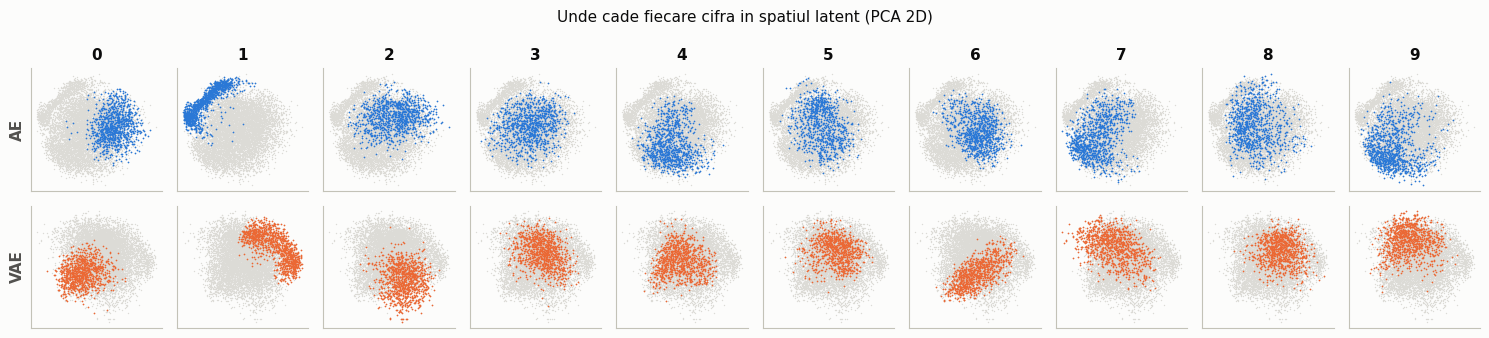

In [13]:
fig, axe = plt.subplots(2, 10, figsize=(15, 3.4))
for r, (P, c_model, nume) in enumerate([(P_ae, C_AE, "AE"), (P_vae, C_VAE, "VAE")]):
    for c in range(10):
        ax = axe[r, c]
        ax.scatter(P[:, 0], P[:, 1], s=1, color="#dcdbd6", linewidths=0)
        m = y_test == c
        ax.scatter(P[m, 0], P[m, 1], s=1.5, color=c_model, linewidths=0)
        ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        if r == 0: ax.set_title(str(c), fontsize=11, fontweight="bold")
    axe[r, 0].set_ylabel(nume, fontsize=11, fontweight="bold")
fig.suptitle("Unde cade fiecare cifra in spatiul latent (PCA 2D)", fontsize=11)
plt.tight_layout(); plt.show()

## 8. Concluzii

In [14]:
print(f"{'':<34}{'AE clasic':>12}{'VAE':>12}")
print("-" * 58)
print(f"{'BCE / pixel (reconstructie)':<34}{bce(x_test, rec_ae):>12.4f}{bce(x_test, rec_vae):>12.4f}")
print(f"{'raport gol in spatiul latent':<34}{gol_ae:>12.2f}{gol_vae:>12.2f}")
print(f"{'dimensiuni latente folosite':<34}{'32/32':>12}{f'{int((kl_dim > 0.01).sum())}/32':>12}")
print(f"{'epoci pana la convergenta':<34}{ist_ae['epoca_best']:>12}{ist_vae['epoca_best']:>12}")
print(f"{'generare din z aleator':<34}{'mazgaleli':>12}{'cifre':>12}")

                                     AE clasic         VAE
----------------------------------------------------------


BCE / pixel (reconstructie)             0.0775      0.0945
raport gol in spatiul latent              1.95        1.05
dimensiuni latente folosite              32/32       16/32
epoci pana la convergenta                  130         124
generare din z aleator               mazgaleli       cifre


**Niciunul dintre modele nu e mai bun în general. Fiecare e potrivit pentru altă sarcină.**

- **AE clasic comprimă mai bine.** Reconstrucțiile sunt mai precise (BCE mai mic, la fiecare cifră în parte). Spațiul latent are însă goluri mari între coduri, iar un z inventat produce mâzgăleli. Pentru compresie, de exemplu imagini medicale unde detaliul fin contează, AE e alegerea potrivită.
- **VAE generează.** Termenul KL umple golurile, iar orice z din N(0,1) cade printre coduri cunoscute, deci decoderul produce cifre plauzibile care n-au existat în setul de date. Prețul: reconstrucții mai încețoșate, pentru că fiecare imagine ocupă un nor, nu un punct.
- **Observații din experimente:**
  - La AE, gâtul de 32 de numere funcționează ca regularizator: diferența train/validare rămâne sub 0.002 chiar după 134 de epoci.
  - Informația despre cifră apare fără etichete: un clasificator liniar pe cele 32 de numere din AE atinge 90.3%, cât pe toți cei 784 de pixeli (90.4%).
  - AE reconstruiește corect și cifre nevăzute la antrenare: antrenat fără niciun 9, reconstruiește 9-urile la fel de bine ca restul. A învățat trăsături (linii, bucle, capete de linie), nu categorii.
  - Loss-ul VAE trebuie sumat pe pixeli. Cu media implicită din Keras, echivalentul unui β = 784, modelul a ignorat complet intrarea.